Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


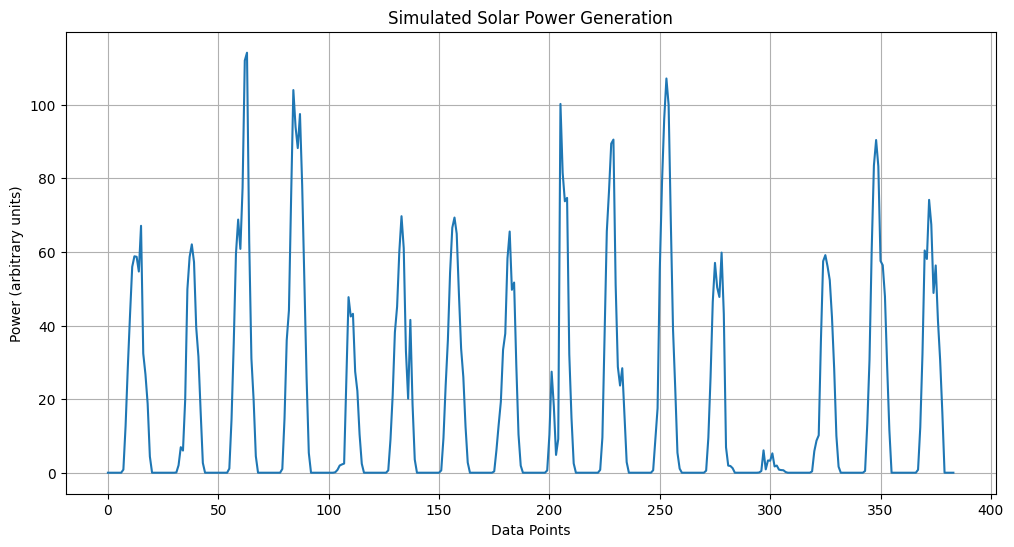

count    384.000000
mean      18.358553
std       27.503339
min        0.000000
25%        0.000000
50%        0.698817
75%       32.183543
max      114.148627
Name: solar_power, dtype: float64

Data point with maximum power generation:
temp: 34.0
dew: 22.0
humidity: 49.65
precipitation: 0.5
snow: 0.0
snowdepth: 0.0
windgust: 14.0
windspeed: 13.0
winddir: 330.0
cloudcover: 50.0
visibility: 5.0
solar_radiation: 833.0
solar_power: 114.14862705836134
File ID: 1ZQ7zxBRgNQ5Iycxx9lE4kHgUoMJyyvd0
Data successfully saved to solar_power_output.xlsx in Google Drive


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import auth
from google.colab import drive
from google.colab import files
from googleapiclient.discovery import build
from googleapiclient.http import MediaIoBaseDownload, MediaIoBaseUpload
from io import BytesIO

# Authenticate and mount Google Drive
auth.authenticate_user()
drive.mount('/content/drive')

# Create a Google Drive API client
drive_service = build('drive', 'v3')

def read_excel_from_drive(file_name):
    try:
        file_path = f'/content/drive/My Drive/{file_name}'
        return pd.read_excel(file_path)
    except FileNotFoundError:
        print(f"File not found: {file_name}")
        return None

def simulate_solar_power(weather_data):
    # Base power calculation using solar radiation
    power = weather_data['solar_radiation'] * 0.2

    # Apply effects of various weather conditions
    power *= (1 - weather_data['cloudcover'] / 200)  # Cloud cover effect
    power *= (1 + (weather_data['temp'] - 25) * 0.005)  # Temperature effect
    power *= (1 - weather_data['humidity'] / 200)  # Humidity effect
    power *= (1 - weather_data['precipitation'] / 100)  # Precipitation effect
    power *= (1 - weather_data['snow'] / 20)  # Snow effect
    power *= (1 + weather_data['visibility'] / 20)  # Visibility effect

    # Additional factors (simplified effects)
    power *= (1 - weather_data['windspeed'] / 200)  # Wind speed effect
    power *= (1 - weather_data['snowdepth'] / 50)  # Snow depth effect

    # Ensure power is non-negative
    return np.maximum(power, 0)

def save_to_excel_in_drive(df, file_name):
    try:
        # Save DataFrame to a BytesIO object
        output = BytesIO()
        with pd.ExcelWriter(output, engine='openpyxl') as writer:
            df.to_excel(writer, index=False)
        output.seek(0)

        # Upload the file to Google Drive
        file_metadata = {'name': file_name}
        media = MediaIoBaseUpload(output, mimetype='application/vnd.openxmlformats-officedocument.spreadsheetml.sheet')
        file = drive_service.files().create(body=file_metadata, media_body=media, fields='id').execute()

        print(f"File ID: {file.get('id')}")
        print(f"Data successfully saved to {file_name} in Google Drive")
    except Exception as e:
        print(f"Error saving file: {e}")

# Main execution
if __name__ == "__main__":
    # Specify the name of your input Excel file in Google Drive
    input_file_name = 'Forcast.xlsx'

    # Read the weather data
    weather_data = read_excel_from_drive(input_file_name)

    if weather_data is not None:
        # Confirm the columns in the data
        expected_columns = ['temp', 'dew', 'humidity', 'precipitation', 'snow', 'snowdepth',
                            'windgust', 'windspeed', 'winddir', 'cloudcover', 'visibility',
                            'solar_radiation']
        missing_columns = [col for col in expected_columns if col not in weather_data.columns]
        if missing_columns:
            print(f"Warning: The following expected columns are missing: {missing_columns}")

        # Simulate solar power generation
        weather_data['solar_power'] = simulate_solar_power(weather_data)

        # Plot results
        plt.figure(figsize=(12, 6))
        plt.plot(weather_data.index, weather_data['solar_power'])
        plt.title('Simulated Solar Power Generation')
        plt.xlabel('Data Points')
        plt.ylabel('Power (arbitrary units)')
        plt.grid(True)
        plt.show()

        # Display summary statistics
        print(weather_data['solar_power'].describe())

        # Example: Find the day with maximum power generation
        max_power_day = weather_data.loc[weather_data['solar_power'].idxmax()]
        print("\nData point with maximum power generation:")
        for col in expected_columns + ['solar_power']:
            if col in max_power_day.index:
                print(f"{col}: {max_power_day[col]}")

        # Specify the name for your output Excel file in Google Drive
        output_file_name = 'solar_power_output.xlsx'

        # Save the results
        save_to_excel_in_drive(weather_data, output_file_name)
    else:
        print("Could not proceed with the simulation due to missing input data.")

Mounted at /content/drive


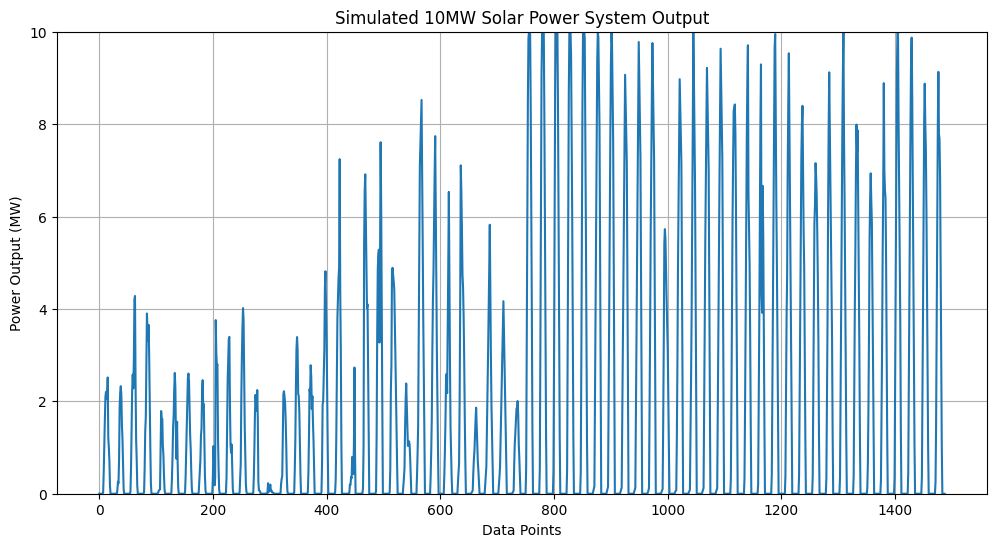

count    1488.000000
mean        1.839486
std         2.782903
min         0.000000
25%         0.000000
50%         0.072023
75%         2.828990
max        10.000000
Name: solar_power_mw, dtype: float64

Data point with maximum power generation:
temp: 33.2
dew: 22.3
humidity: 52.87
precipitation: 0.0
snow: 0.0
snowdepth: 0.0
windgust: 15.1
windspeed: 16.9
winddir: 274.7
cloudcover: 0.0
visibility: 24.1
solar_radiation: 916.0
solar_power_mw: 10.0
File ID: 1-93EFbzAAg-qccbiRdgIQUvMf6loKd6r
Data successfully saved to solar_power_10MW_output.xlsx in Google Drive


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import auth
from google.colab import drive
from google.colab import files
from googleapiclient.discovery import build
from googleapiclient.http import MediaIoBaseDownload, MediaIoBaseUpload
from io import BytesIO

# Authenticate and mount Google Drive
auth.authenticate_user()
drive.mount('/content/drive')

# Create a Google Drive API client
drive_service = build('drive', 'v3')

def read_excel_from_drive(file_name):
    try:
        file_path = f'/content/drive/My Drive/{file_name}'
        return pd.read_excel(file_path)
    except FileNotFoundError:
        print(f"File not found: {file_name}")
        return None

def simulate_solar_power(weather_data):
    # Constants for a 10MW system
    SYSTEM_CAPACITY = 10  # MW
    SYSTEM_EFFICIENCY = 0.15  # Typical efficiency for large-scale solar PV

    # Assume peak sun hours of 5 (you may adjust this based on your location)
    PEAK_SUN_HOURS = 5

    # Calculate base power output
    max_daily_energy = SYSTEM_CAPACITY * PEAK_SUN_HOURS  # MWh

    # Normalize solar radiation to a 0-1 scale (assuming max radiation is 1000 W/m^2)
    normalized_radiation = weather_data['solar_radiation'] / 1000

    # Calculate power based on normalized radiation and system characteristics
    power = normalized_radiation * max_daily_energy * SYSTEM_EFFICIENCY

    # Apply weather effects
    power *= (1 - weather_data['cloudcover'] / 200)  # Cloud cover effect
    power *= (1 + (weather_data['temp'] - 25) * 0.005)  # Temperature effect
    power *= (1 - weather_data['humidity'] / 200)  # Humidity effect
    power *= (1 - weather_data['precipitation'] / 100)  # Precipitation effect
    power *= (1 - weather_data['snow'] / 20)  # Snow effect
    power *= (1 + weather_data['visibility'] / 20)  # Visibility effect
    power *= (1 - weather_data['windspeed'] / 200)  # Wind speed effect
    power *= (1 - weather_data['snowdepth'] / 50)  # Snow depth effect

    # Ensure power is non-negative and doesn't exceed system capacity
    return np.clip(power, 0, SYSTEM_CAPACITY)

def save_to_excel_in_drive(df, file_name):
    try:
        output = BytesIO()
        with pd.ExcelWriter(output, engine='openpyxl') as writer:
            df.to_excel(writer, index=False)
        output.seek(0)

        file_metadata = {'name': file_name}
        media = MediaIoBaseUpload(output, mimetype='application/vnd.openxmlformats-officedocument.spreadsheetml.sheet')
        file = drive_service.files().create(body=file_metadata, media_body=media, fields='id').execute()

        print(f"File ID: {file.get('id')}")
        print(f"Data successfully saved to {file_name} in Google Drive")
    except Exception as e:
        print(f"Error saving file: {e}")

# Main execution
if __name__ == "__main__":
    input_file_name = 'Forcast.xlsx'

    weather_data = read_excel_from_drive(input_file_name)

    if weather_data is not None:
        expected_columns = ['temp', 'dew', 'humidity', 'precipitation', 'snow', 'snowdepth',
                            'windgust', 'windspeed', 'winddir', 'cloudcover', 'visibility',
                            'solar_radiation']
        missing_columns = [col for col in expected_columns if col not in weather_data.columns]
        if missing_columns:
            print(f"Warning: The following expected columns are missing: {missing_columns}")

        weather_data['solar_power_mw'] = simulate_solar_power(weather_data)

        plt.figure(figsize=(12, 6))
        plt.plot(weather_data.index, weather_data['solar_power_mw'])
        plt.title('Simulated 10MW Solar Power System Output')
        plt.xlabel('Data Points')
        plt.ylabel('Power Output (MW)')
        plt.ylim(0, 10)  # Set y-axis limit to system capacity
        plt.grid(True)
        plt.show()

        print(weather_data['solar_power_mw'].describe())

        max_power_day = weather_data.loc[weather_data['solar_power_mw'].idxmax()]
        print("\nData point with maximum power generation:")
        for col in expected_columns + ['solar_power_mw']:
            if col in max_power_day.index:
                print(f"{col}: {max_power_day[col]}")

        output_file_name = 'solar_power_10MW_output.xlsx'

        save_to_excel_in_drive(weather_data, output_file_name)
    else:
        print("Could not proceed with the simulation due to missing input data.")